# **Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# **Load the Data**

In [ ]:
#Superstore Sales Dataset dowmloaded from Kaggle

df = pd.read_csv("/content/sample_data/train.csv.zip")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# **Data Cleaning**

In [ ]:
# Checking nulls
print(df.isnull().sum())

# Converting date
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Creating new columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Calculating profit (example: assuming 10% profit margin on Sales)
df['Profit'] = df['Sales'] * 0.10

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
dtype: int64


# **Doing Basic Exploration**

In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(9800, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Catego

# **EDA & Charts**

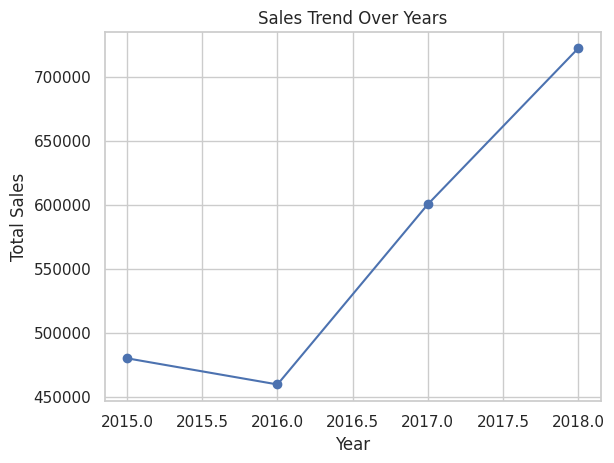

In [ ]:
#Sales Over Time

sales_trend = df.groupby('Year')['Sales'].sum()

sales_trend.plot(kind='line', marker='o')
plt.title("Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

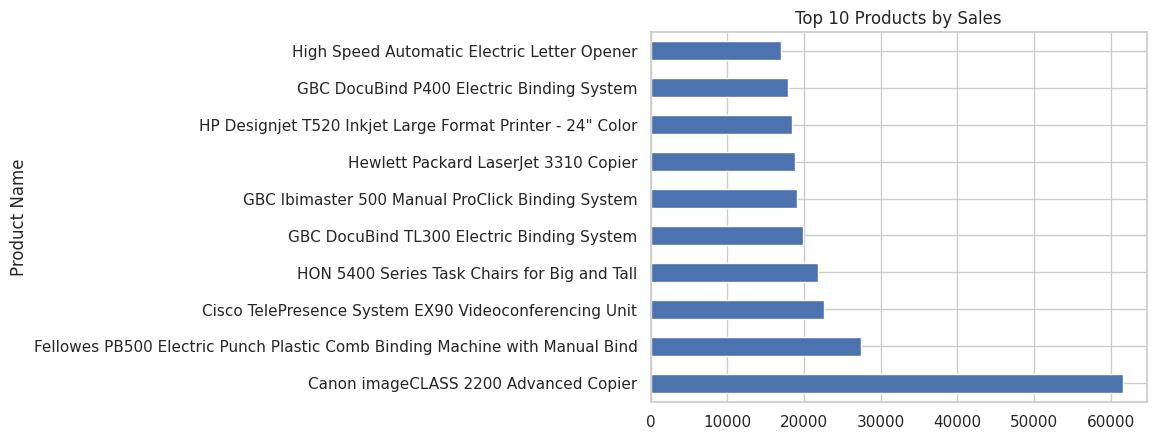

In [ ]:
#Top 10 Products

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh')
plt.title("Top 10 Products by Sales")
plt.show()

In [ ]:
#Profit Calculation

df['Profit'] = df['Sales'] * 0.10
print(df['Profit'] )

0       26.19600
1       73.19400
2        1.46200
3       95.75775
4        2.23680
          ...   
9795     0.37980
9796     1.03680
9797    23.51880
9798     2.63760
9799     1.03840
Name: Profit, Length: 9800, dtype: float64


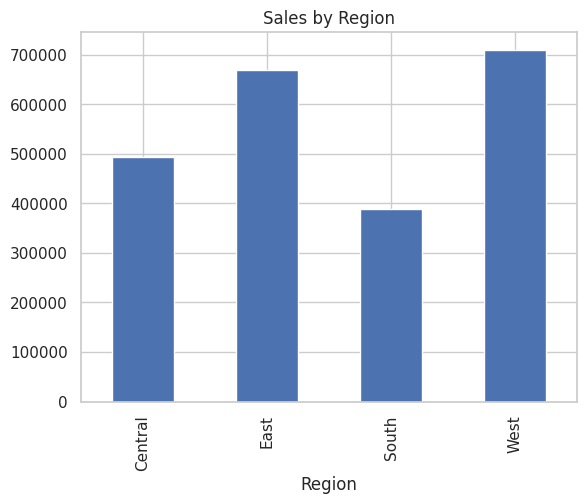

In [ ]:
#Sales by Region

region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

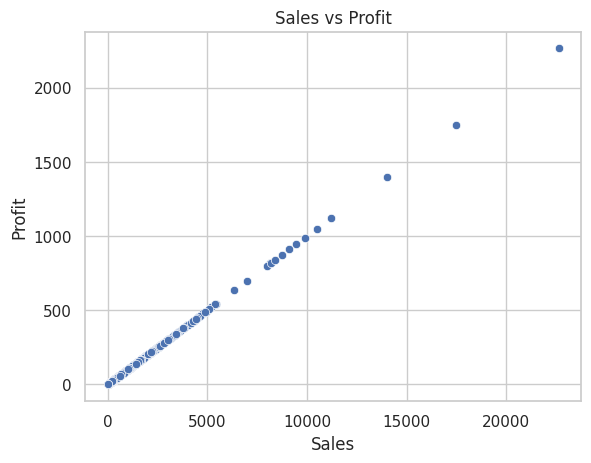

In [ ]:
#Profit vs Sales

sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

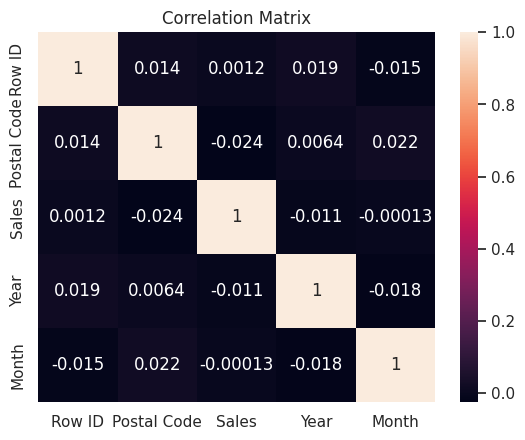

In [ ]:
#Correlation Heatmap

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

# ***KEY INSIGHTS***

1. Sales increased steadily over the years, indicating business growth
2. Technology category contributes highest revenue
3. Some high-sales transactions show low/negative profit because of discount issue
4. West region performs best overall
5. Strong correlation between Sales and Profit, but not always consistent

# ***THANK YOU***